In [1]:
# step 1: import and setup 
import numpy as np                  # Numerical operations (arrays, math and fast computation)
import pandas as pd                # data manipulation (tables, CSV handling)
import matplotlib.pyplot as plt   # visualization -> plotting graphs
import json                       # save results in JSON format (for reports / reuse)
import joblib                     # load trained sklearn models (random forest)
import os


# ML tools
from sklearn.inspection import permutation_importance # shuffles one features at a time and eausres performance drop
from sklearn.metrics import accuracy_score  # used to evaluate classification performance(especially for CNN wrapper)

# DL 
import tensorflow as tf # to load and run CNN/ Autoencorder models

# clean output
import warnings 
warnings.filterwarnings('ignore') # suppresses worings so output s clean (not cluttered)

# sanity check
print("Libraries loaded!")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")
print(f"TensorFlow version:  {tf.__version__}")

2026-05-15 12:31:37.419423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries loaded!
Scikit-learn version: 1.6.1
TensorFlow version:  2.16.2


In [6]:
# Step 2: Load data and models 
base_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# data paths
X_test_path       = os.path.join(base_path, "X_test.npy")
y_test_path       = os.path.join(base_path, "y_test.csv")
feature_names = pd.read_csv(feature_names_path).iloc[:, 0].tolist()

# model paths 
rf_model_path  = os.path.join(base_path, "rf_model.joblib")
cnn_model_path = os.path.join(base_path, "cnn_model.keras")
ae_model_path  = os.path.join(base_path, "ae_model.keras")

# load data
X_test       = np.load(X_test_path)
y_test       = pd.read_csv(y_test_path).squeeze()
feature_names = pd.read_csv(feature_names_path).iloc[:, 0].tolist()

# Read the CSV file treating everything as data, grab the first column, convert to a list
# iloc = integer location; [:] = all rows; [0] = first column; 
#.tolist() → converts the pandas Series into a plain Python list

assert len(feature_names) == X_test.shape[1], "Feature mismatch!"
print("Data loaded successfully!")
print(f"X_test shape:       {X_test.shape}")
print(f"y_test shape:       {y_test.shape}")
print(f"Number of features: {len(feature_names)}")

# load models
rf_model  = joblib.load(rf_model_path)
cnn_model = tf.keras.models.load_model(cnn_model_path)
ae_model  = tf.keras.models.load_model(ae_model_path)

print("\nModels loaded successfully!")
print(f"RF model type:    {type(rf_model)}")
print(f"CNN model loaded: {cnn_model is not None}")
print(f"AE model loaded:  {ae_model is not None}")
print(f"Feature count:    {len(feature_names)}")
print(f"X_test features:  {X_test.shape[1]}")
print(f"First 5 features: {feature_names[:5]}")

Data loaded successfully!
X_test shape:       (848363, 80)
y_test shape:       (848363,)
Number of features: 80

Models loaded successfully!
RF model type:    <class 'sklearn.ensemble._forest.RandomForestClassifier'>
CNN model loaded: True
AE model loaded:  True
Feature count:    80
X_test features:  80
First 5 features: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets']


In [4]:
# check what's in feature_names.csv
import pandas as pd
save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# check with header=None
df1 = pd.read_csv(save_path + "feature_names.csv", header=None)
print(f"With header=None: {len(df1)} rows")
print(f"First 5 rows:\n{df1.head()}")

# check without header=None
df2 = pd.read_csv(save_path + "feature_names.csv")
print(f"\nWithout header=None: {len(df2)} rows")
print(f"First 5 rows:\n{df2.head()}")

print(f"\nX_test features: {X_test.shape[1]}")

With header=None: 81 rows
First 5 rows:
                  0
0                 0
1       Source Port
2  Destination Port
3          Protocol
4     Flow Duration

Without header=None: 80 rows
First 5 rows:
                   0
0        Source Port
1   Destination Port
2           Protocol
3      Flow Duration
4  Total Fwd Packets

X_test features: 80


In [7]:
# step 3: permutation importance on random forest
# rf is easiest - sklearn build-in words directly
# sample 1000 rows for speed (same pattern as shap notebooks)

import time
print ("Running Permutation Importance on Randon Forest...")
print("Using 10,000 sample rows for speed...")

# Sample for speed 
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 10000, replace=False)
X_sample   = X_test[sample_idx]
y_sample   = y_test.iloc[sample_idx]

start = time.time()

# Run permutation importance
# n_repeats=10 means each feature is shffued 10 times for stable results
rf_perm = permutation_importance(
    rf_model,             # trained RF model
    X_sample,             # sampled test data
    y_sample,             # true labels
    n_repeats = 10,       # shuffle each feature 10 times
    random_state=42,
    scoring='accuracy',  # measure accuracy drop when feature is shuffled
    n_jobs=-1             # use all CPU cores for speed; n_jons=1 -> only use one core
)

elapsed = round(time.time() - start, 2)
# time.time() -> record start time(in seconds)
# round(time.time() - start, 2)-> final time - start time then record it with 2 decimal


print(f"\nDone, Time taken: {elapsed} seconds")
print(f"Result shape: {rf_perm.importances_mean.shape}")


Running Permutation Importance on Randon Forest...
Using 10,000 sample rows for speed...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.8s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.8s finis


Done, Time taken: 174.33 seconds
Result shape: (80,)


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


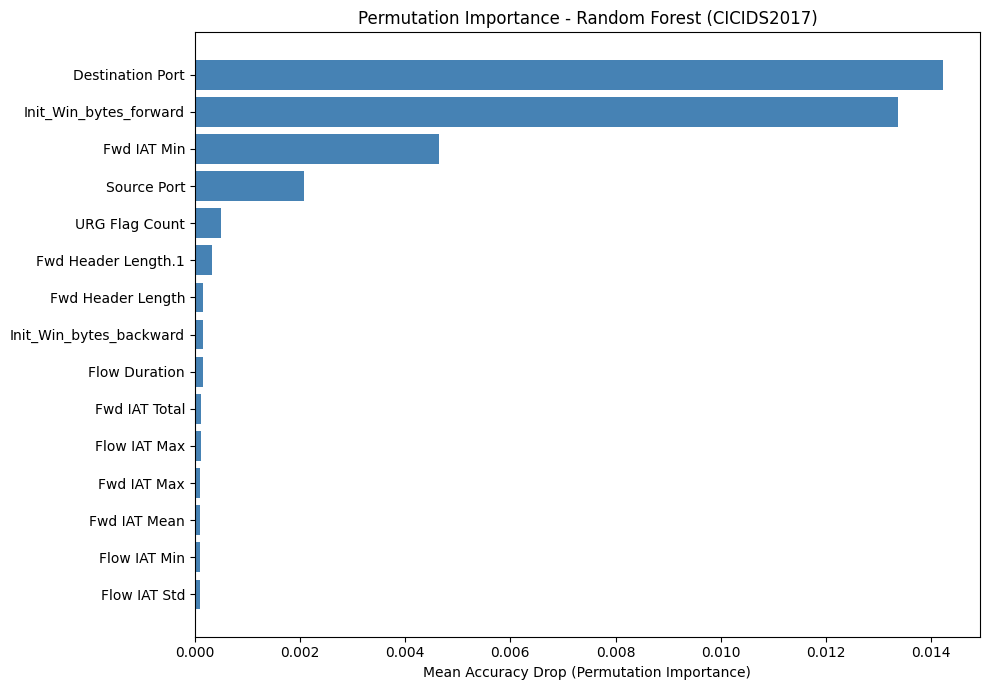

JSON saved!

Top 10 Features — RF Permutation Importance:
Rank   Feature                             Importance Score    
--------------------------------------------------------------
  1    Destination Port                    0.014220
  2    Init_Win_bytes_forward              0.013380
  3    Fwd IAT Min                         0.004640
  4    Source Port                         0.002070
  5    URG Flag Count                      0.000500
  6    Fwd Header Length.1                 0.000320
  7    Fwd Header Length                   0.000150
  8    Init_Win_bytes_backward             0.000150
  9    Flow Duration                       0.000150
  10   Fwd IAT Total                       0.000120

Plot saved:  perm_rf_global.png
JSON saved:  perm_rf_results.json


In [8]:
# Step 4: Plot and save RF Permutation Importance results
save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Get top 15 features sorted by importance
top_idx = np.argsort(rf_perm.importances_mean)[::-1][:15]
top_features = [feature_names[i].strip() for i in top_idx]
top_scores = rf_perm.importances_mean[top_idx]

# plot
plt.figure(figsize=(10,7)) # size of feature 
plt.barh(top_features[::-1], top_scores[::-1], color='steelblue') 
# barh => h=horizontal; top_features[::-1] -> on Y-axis: #1 is at top
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance - Random Forest (CICIDS2017)')
plt.tight_layout()
plt.savefig(save_path + "perm_rf_global.png", dpi=150, bbox_inches='tight')
plt.show()

# save JSON
results = {
    "Model": "RandomForest",
    "xai_method": "Permutation Importance",
    "sample_size": 10000,
    "n_repeats": 10,
    "time_seconds": elapsed,
    "top_15_features":{
        feature_names[i].strip(): round(float(rf_perm.importances_mean[i]),6)
        for i in top_idx
    }
}

with open(save_path + "perm_rf_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("JSON saved!")

# print top 10 as table 
print("\nTop 10 Features — RF Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Importance Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx[:10]):
    feat  = feature_names[idx].strip()
    score = rf_perm.importances_mean[idx]
    print(f"  {i+1:<4} {feat:<35} {score:.6f}")

print("\nPlot saved:  perm_rf_global.png")
print("JSON saved:  perm_rf_results.json")
          


In [9]:
# Step 5: permutation importance on 1D-CNN
# CNN needs 3D input (samples, 80, 1) - must reshape before each prediction
# we manually shuffle each feature and measure accuracy drop

import time 
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

print("Runing Permutation Importance on ID-CNN...")
print("Using same 10,000 sample rows...")
print("Warning: this will take ~15-30 minutes (no perallelization for CNN)")

#Re-encode labels (same as cn_model.ipynb)
le = LabelEncoder()
le.fit(y_test)
y_sample_enc = le.transform(y_test.iloc[sample_idx])

# Use same sample_idx as RF for fair comparison
X_sample_cnn = X_test[sample_idx]

# step 1: baseline accuracy
X_sample_3d = X_sample_cnn.reshape(X_sample_cnn.shape[0], X_sample_cnn.shape[1],1)
baseline_pred = np.argmax(cnn_model.predict(X_sample_3d, verbose=0), axis=1)
baseline_acc = accuracy_score(y_sample_enc, baseline_pred)
print(f"\nBaseline CNN accuracy on sample: {baseline_acc:.4f}")

# Step 2: shuffle each feature and measure accuracy drop 
n_repeats = 10
cnn_importances = np.zeros(X_sample_cnn.shape[1])

start = time.time()

for feat_idx in range(X_sample_cnn.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_sample_cnn.copy()
        np.random.shuffle(X_perm[:, feat_idx]) # shuffle one feature
        X_perm_3d = X_perm.reshape(X_perm.shape[0], X_perm.shape[1], 1)
        perm_pred = np.argmax(cnn_model.predict(X_perm_3d, verbose=0), axis=1)
        perm_acc = accuracy_score(y_sample_enc, perm_pred)
        drops.append(baseline_acc - perm_acc) # accuracy drop
    cnn_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f" Progress: {feat_idx}/80 features done...")
elapsed_cnn = round(time.time() - start, 2)
print(f"\nDone! Time taken: {elapsed_cnn} seconds")

# Top 10
top_idx_cnn = np.argsort(cnn_importances)[::-1][:10]
print("\nTop 10 feature (CNN Permutation Importance):")
print(f"{'Rank': <6} {'Feature' :<35} {'Importance Score' :<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_cnn):
    print(f" {i+1:<4} {feature_names[idx].strip():<35} {cnn_importances[idx]:.6f}")

    

Runing Permutation Importance on ID-CNN...
Using same 10,000 sample rows...

Baseline CNN accuracy on sample: 0.9852
 Progress: 0/80 features done...
 Progress: 10/80 features done...
 Progress: 20/80 features done...
 Progress: 30/80 features done...
 Progress: 40/80 features done...
 Progress: 50/80 features done...
 Progress: 60/80 features done...
 Progress: 70/80 features done...

Done! Time taken: 1467.31 seconds

Top 10 feature (CNN Permutation Importance):
Rank   Feature                             Importance Score    
--------------------------------------------------------------
 1    Bwd Packets/s                       0.040130
 2    Down/Up Ratio                       0.034830
 3    PSH Flag Count                      0.034360
 4    Min Packet Length                   0.029310
 5    ACK Flag Count                      0.023600
 6    Init_Win_bytes_forward              0.021330
 7    Bwd Packet Length Std               0.018410
 8    Source Port                         0.017

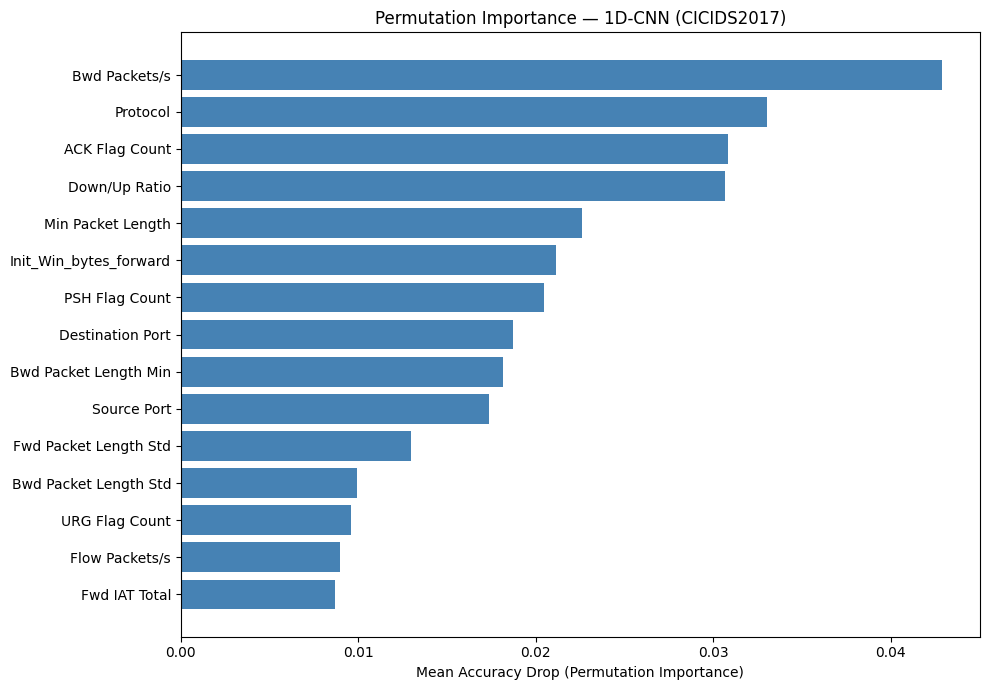

Plot saved!
JSON saved!

Top 10 Features — CNN Permutation Importance:
Rank   Feature                             Importance Score    
--------------------------------------------------------------
  1    Bwd Packets/s                       0.042880
  2    Protocol                            0.033010
  3    ACK Flag Count                      0.030850
  4    Down/Up Ratio                       0.030680
  5    Min Packet Length                   0.022590
  6    Init_Win_bytes_forward              0.021160
  7    PSH Flag Count                      0.020480
  8    Destination Port                    0.018710
  9    Bwd Packet Length Min               0.018160
  10   Source Port                         0.017380


In [29]:
# Cell 6: Plot and save CNN Permutation Importance results
# Get top 15 features
top_idx_cnn_15 = np.argsort(cnn_importances)[::-1][:15]
top_features_cnn = [feature_names[i].strip() for i in top_idx_cnn_15]
top_scores_cnn   = cnn_importances[top_idx_cnn_15]

# Plot
plt.figure(figsize=(10, 7))
plt.barh(top_features_cnn[::-1], top_scores_cnn[::-1], color='steelblue')
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance — 1D-CNN (CICIDS2017)')
plt.tight_layout()
plt.savefig(save_path + "perm_cnn_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# Save JSON
results_cnn = {
    "model": "1D-CNN",
    "xai_method": "Permutation Importance",
    "sample_size": 10000,
    "n_repeats": 10,
    "time_seconds": elapsed_cnn,
    "top_15_features": {
        feature_names[i].strip(): round(float(cnn_importances[i]), 6)
        for i in top_idx_cnn_15
    }
}
with open(save_path + "perm_cnn_results.json", "w") as f:
    json.dump(results_cnn, f, indent=2)
print("JSON saved!")

# Print table
print("\nTop 10 Features — CNN Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Importance Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_cnn_15[:10]):
    print(f"  {i+1:<4} {feature_names[idx].strip():<35} {cnn_importances[idx]:.6f}")

In [30]:
# Step 7: Permutation Importance on Autoencoder
# AE uses MSE reconstruction error — no class labels needed
# It measure how much accuracy drops when each feature is shuffled

import time
from sklearn.metrics import accuracy_score

print("Running Permutation Importance on Autoencoder...")
print("Using same 10,000 sample rows...")

# Use same sample_idx for fair comparison
X_sample_ae = X_test[sample_idx]
y_sample_ae = y_test.iloc[sample_idx].reset_index(drop=True)

# Step 1: baseline MSE and accuracy
X_pred_base = ae_model.predict(X_sample_ae, batch_size=1024, verbose=0)
mse_base    = np.mean(np.power(X_sample_ae - X_pred_base, 2), axis=1)

# Threshold: 95th percentile of BENIGN samples (same as your AE notebook)
normal_mse = mse_base[y_sample_ae == 0]
threshold  = np.percentile(normal_mse, 95)

y_pred_base   = (mse_base > threshold).astype(int)
y_true_binary = (y_sample_ae != 0).astype(int)
baseline_acc  = accuracy_score(y_true_binary, y_pred_base)

print(f"\nBaseline AE accuracy on sample: {baseline_acc:.4f}")
print(f"Threshold: {threshold:.6f}")

# Step 2: shuffle each feature and measure accuracy drop
n_repeats = 10
ae_importances = np.zeros(X_sample_ae.shape[1])

start = time.time()

for feat_idx in range(X_sample_ae.shape[1]):
    drops = []
    for _ in range(n_repeats):
        X_perm      = X_sample_ae.copy()
        np.random.shuffle(X_perm[:, feat_idx])
        X_pred_perm = ae_model.predict(X_perm, batch_size=1024, verbose=0)
        mse_perm    = np.mean(np.power(X_perm - X_pred_perm, 2), axis=1)
        y_pred_perm = (mse_perm > threshold).astype(int)
        perm_acc    = accuracy_score(y_true_binary, y_pred_perm)
        drops.append(baseline_acc - perm_acc)
    ae_importances[feat_idx] = np.mean(drops)
    if feat_idx % 10 == 0:
        print(f"  Progress: {feat_idx}/80 features done...")

elapsed_ae = round(time.time() - start, 2)
print(f"\nDone! Time taken: {elapsed_ae} seconds")

# Top 10
top_idx_ae = np.argsort(ae_importances)[::-1][:10]
print("\nTop 10 features (AE Permutation Importance):")
print(f"{'Rank':<6} {'Feature':<35} {'Importance Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_ae):
    print(f"  {i+1:<4} {feature_names[idx].strip():<35} {ae_importances[idx]:.6f}")

Running Permutation Importance on Autoencoder...
Using same 10,000 sample rows...

Baseline AE accuracy on sample: 0.8569
Threshold: 0.060618
  Progress: 0/80 features done...
  Progress: 10/80 features done...
  Progress: 20/80 features done...
  Progress: 30/80 features done...
  Progress: 40/80 features done...
  Progress: 50/80 features done...
  Progress: 60/80 features done...
  Progress: 70/80 features done...

Done! Time taken: 131.55 seconds

Top 10 features (AE Permutation Importance):
Rank   Feature                             Importance Score    
--------------------------------------------------------------
  1    Protocol                            0.141840
  2    Flow Duration                       0.130330
  3    Fwd IAT Total                       0.127510
  4    Bwd IAT Total                       0.103350
  5    PSH Flag Count                      0.097790
  6    Average Packet Size                 0.092750
  7    Packet Length Mean                  0.089850
  8    F

In [14]:
# Load ae_importances from saved JSON
import json
import numpy as np

with open(save_path + "perm_ae_results.json", "r") as f:
    saved_ae = json.load(f)

# rebuild ae_importances as full 80-feature array
ae_importances = np.zeros(len(feature_names))
for feat_name, score in saved_ae["top_15_features"].items():
    feat_name_stripped = feat_name.strip()
    for i, fn in enumerate(feature_names):
        if fn.strip() == feat_name_stripped:
            ae_importances[i] = score
            break

elapsed_ae = saved_ae["time_seconds"]
threshold = saved_ae["threshold"]

print(f"ae_importances loaded: {ae_importances.shape}")
print(f"Non-zero values: {np.count_nonzero(ae_importances)}")

ae_importances loaded: (80,)
Non-zero values: 15


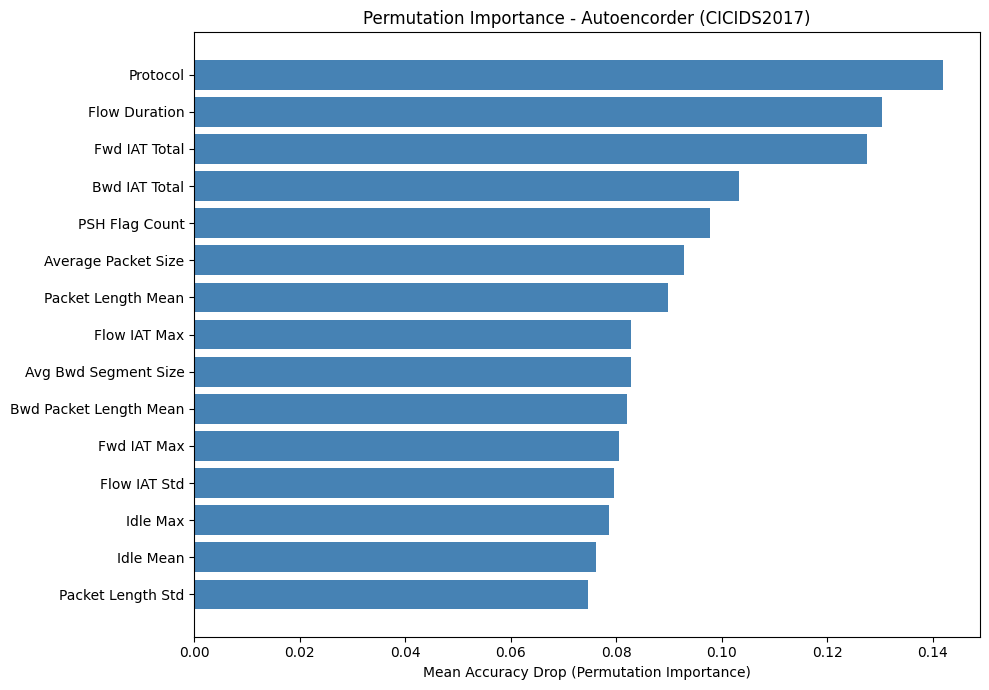

Plot saved!
JSON saved!

Top Features - AE Permutation Importance:
Rank   Feature                             Importance Score    
--------------------------------------------------------------
  1    Protocol                            0.141840
  2    Flow Duration                       0.130330
  3    Fwd IAT Total                       0.127510
  4    Bwd IAT Total                       0.103350
  5    PSH Flag Count                      0.097790
  6    Average Packet Size                 0.092750
  7    Packet Length Mean                  0.089850
  8    Flow IAT Max                        0.082860
  9    Avg Bwd Segment Size                0.082760
  10   Bwd Packet Length Mean              0.081970


In [17]:
# Step 8: Plot and asve AE permutation importance results
# get top 15 features 
top_idx_ae_15 = np.argsort(ae_importances)[::-1][:15]
top_features_ae = [feature_names[i].strip() for i in top_idx_ae_15]
top_scores_ae = ae_importances[top_idx_ae_15]

# plot
plt.figure(figsize=(10,7))
plt.barh(top_features_ae[::-1], top_scores_ae[::-1], color='steelblue')
plt.xlabel('Mean Accuracy Drop (Permutation Importance)')
plt.title('Permutation Importance - Autoencorder (CICIDS2017)')
plt.tight_layout()
plt.savefig(save_path + "perm_ae_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# Save JSON
results_ae = {
    "model": "Autoencoder",
    "xai_method": "Permutation Importance",
    "sample_size": 10000,
    "n_repeats": 10,
    "time_seconds": elapsed_ae,
    "threshold": round(float(threshold),6),
    "top_15_features": {
        feature_names[i].strip(): round(float(ae_importances[i]), 6)
        for i in top_idx_ae_15
    }
}

with open(save_path + "perm_ae_results.json", "w") as f:
    json.dump(results_ae, f, indent=2)
print("JSON saved!")

# print table 
print("\nTop Features - AE Permutation Importance:")
print(f"{'Rank':<6} {'Feature':<35} {'Importance Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_ae_15[:10]):
    print(f"  {i+1:<4} {feature_names[idx].strip():<35} {ae_importances[idx]:.6f}")




    

In [16]:
# Step 9: Cross-model comparison summary
# Compare top features across RF, CNN, AE for all three XAI methods

print("=" * 70) # make a lne shape: ====
print("CROSS-MODEL PERMUTATION IMPORTANCE COMPARISON (CICIDS2017)")
print("=" * 70)

print("\n--- Top 5 Features by Model ---")
print(f"{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
# {'Rank':<6} -> left-align and use 6 characters wide
print("-" * 96)

top_rf  = [feature_names[i].strip() for i in np.argsort(rf_perm.importances_mean)[::-1][:5]]
top_cnn = [feature_names[i].strip() for i in np.argsort(cnn_importances)[::-1][:5]]
top_ae  = [feature_names[i].strip() for i in np.argsort(ae_importances)[::-1][:5]]

for i in range(5):
    print(f"  {i+1:<4} {top_rf[i]:<30} {top_cnn[i]:<30} {top_ae[i]:<30}")

print("\n--- Key Findings ---")
print("RF  Perm #1:", top_rf[0],  " ← matches SHAP " if top_rf[0] == "Destination Port" else "")
print("CNN Perm #1:", top_cnn[0], " ← matches SHAP " if top_cnn[0] == "Bwd Packets/s" else "")
print("AE  Perm #1:", top_ae[0],  " ← SHAP=FIN Flag Count, LIME=RST Flag Count ⚠️")

# Save summary JSON
summary = {
    "dataset": "CICIDS2017",
    "xai_method": "Permutation Importance",
    "rf_top5":  top_rf,
    "cnn_top5": top_cnn,
    "ae_top5":  top_ae,
    "findings": {
        "rf_perm_vs_shap":  "AGREE on #1 (Destination Port)",
        "cnn_perm_vs_shap": "AGREE on #1 (Bwd Packets/s)",
        "ae_perm_vs_shap":  "DISAGREE — Perm: Protocol, SHAP: FIN Flag Count, LIME: RST Flag Count"
    }
}
with open(save_path + "perm_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSummary JSON saved!")
print("\n All 3 models done")

CROSS-MODEL PERMUTATION IMPORTANCE COMPARISON (CICIDS2017)

--- Top 5 Features by Model ---
Rank   RF                             CNN                            AE                            
------------------------------------------------------------------------------------------------
  1    Destination Port               Bwd Packets/s                  Protocol                      
  2    Init_Win_bytes_forward         Down/Up Ratio                  Flow Duration                 
  3    Fwd IAT Min                    PSH Flag Count                 Fwd IAT Total                 
  4    Source Port                    Min Packet Length              Bwd IAT Total                 
  5    URG Flag Count                 ACK Flag Count                 PSH Flag Count                

--- Key Findings ---
RF  Perm #1: Destination Port  ← matches SHAP 
CNN Perm #1: Bwd Packets/s  ← matches SHAP 
AE  Perm #1: Protocol  ← SHAP=FIN Flag Count, LIME=RST Flag Count ⚠️

Summary JSON saved!

 All 3 

## Permutation Importance Complete — CICIDS2017

| Model | #1 Feature | Matches SHAP? |
|-------|-----------|---------------|
| RF | Destination Port | YES |
| CNN | Bwd Packets/s | YES |
| AE | Protocol | NO (SHAP=FIN Flag, LIME=RST Flag) |

### Key Finding
RF and CNN show consistent XAI explanations across SHAP and
Permutation Importance. Autoencoder shows disagreement —
suggesting unsupervised models produce less stable XAI explanations
than supervised models. This is a core benchmark finding.

### Output Files
- perm_rf_results.json + perm_rf_global.png
- perm_cnn_results.json + perm_cnn_global.png
- perm_ae_results.json + perm_ae_global.png
- perm_summary.json